# 01 · SMS Spam — Coarse Scenario Annotation

**Goal:** classify 747 human-written SMS spam records into coarse scenario families  
using LLM-assisted annotation (OpenRouter / `openai/gpt-4o-mini`).

**Why this matters:** the raw SMS Spam Collection mixes multiple spam genres.  
Only `bank_or_account_phishing` and `delivery_or_service_phishing` are  
methodologically matched to the LLM fraud-SMS prompts. The rest goes to  
auxiliary slices or is discarded from core.

**Outputs:**
- `data/interim/annotated/sms_spam_annotated.jsonl` — all records with new fields
- `data/interim/annotated/sms_spam_annotation_summary.csv` — per-class stats

**Run order:** run all cells top-to-bottom. Annotation is cached —  
re-running skips already-annotated records.

---

**Taxonomy (6 classes)**

| Class | Goes to core? | Description |
|---|---|---|
| `bank_or_account_phishing` | yes | bank, card, account, OTP, login alert, password reset |
| `delivery_or_service_phishing` | conditional | parcel, delivery, tracking, missed package |
| `lottery_or_prize` | no | won prize, free gift, selected winner, claim reward |
| `promo_or_marketing_spam` | no | commercial offer, discount, ad — no threat cue |
| `adult_or_misc_spam` | no | adult content, dating, miscellaneous |
| `unclear_other` | no | too short, gibberish, cannot classify |

In [1]:
# ── 0. Setup ───────────────────────────────────────────────────────────────
import json
import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
from tqdm.auto import tqdm

def _find_v2_root() -> Path:
    """Walk up from this notebook to find the v2/ project root."""
    candidate = Path(globals().get("__vsc_ipynb_file__",
                     globals().get("__file__", "."))).resolve()
    for p in [candidate, *candidate.parents]:
        if (p / "pyproject.toml").exists() and (p / "notebooks").exists():
            return p
    # fallback: search from cwd
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "pyproject.toml").exists() and (p / "notebooks").exists():
            return p
    raise RuntimeError("Cannot find v2/ project root")

V2_ROOT    = _find_v2_root()
RAW_DIR    = V2_ROOT / "data" / "raw" / "collected"
INTERIM    = V2_ROOT / "data" / "interim" / "annotated"
OUT_FIGS   = V2_ROOT / "outputs" / "figures" / "annotation"
OUT_TABLES = V2_ROOT / "outputs" / "tables"

INTERIM.mkdir(parents=True, exist_ok=True)
OUT_FIGS.mkdir(parents=True, exist_ok=True)
OUT_TABLES.mkdir(parents=True, exist_ok=True)

print(f"V2_ROOT : {V2_ROOT}")
print(f"RAW_DIR : {RAW_DIR}")
print(f"INTERIM : {INTERIM}")

env_file = V2_ROOT / ".env"
if env_file.exists():
    load_dotenv(env_file)
else:
    load_dotenv() 

api_key = os.environ.get("OPENROUTER_API_KEY", "")
if not api_key:
    raise EnvironmentError(
        "OPENROUTER_API_KEY not found.\n"
        f"Create {V2_ROOT / '.env'} with:\n"
        "  OPENROUTER_API_KEY=sk-or-..."
    )
print(f"API key : {'*' * 8}{api_key[-6:]}  (loaded)")

# ── OpenRouter client ──────────────────────────────────────────────────────
ANNOTATION_MODEL = "openai/gpt-4o-mini"

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=api_key,
)

print(f"Model   : {ANNOTATION_MODEL}")

V2_ROOT : /Users/askar/projects/antifraud-deepfake-detection/v2
RAW_DIR : /Users/askar/projects/antifraud-deepfake-detection/v2/data/raw/collected
INTERIM : /Users/askar/projects/antifraud-deepfake-detection/v2/data/interim/annotated
API key : ********6ce7eb  (loaded)
Model   : openai/gpt-4o-mini


In [2]:
sms_path = RAW_DIR / "sms_spam.jsonl"
assert sms_path.exists(), f"Not found: {sms_path}"

all_sms = [json.loads(l) for l in sms_path.read_text().splitlines() if l.strip()]
spam_records = [r for r in all_sms if r.get("label") == "spam"]

print(f"Total SMS records : {len(all_sms):,}")
print(f"spam only         : {len(spam_records):,}")
print(f"\nSample record:")
print(json.dumps(spam_records[0], indent=2))

Total SMS records : 5,574
spam only         : 747

Sample record:
{
  "text": "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's",
  "label": "spam",
  "has_url": false,
  "url_count": 0,
  "collection_period": "2006-2012"
}


In [3]:
# ── 2. Taxonomy ────────────────────────────────────────────────────────────
SMS_TAXONOMY = {
    "bank_or_account_phishing": (
        "Urgent alert about bank account, card, OTP, password, login, "
        "verification code, account blocked/suspended, security check."
    ),
    "delivery_or_service_phishing": (
        "Fake parcel delivery notice, tracking link, courier, missed package, "
        "reschedule delivery, customs fee required."
    ),
    "lottery_or_prize": (
        "Winner notification, prize claim, free gift, lucky draw, "
        "selected for reward, cash prize, voucher won."
    ),
    "promo_or_marketing_spam": (
        "Commercial promotion, discount offer, sale, subscription upsell, "
        "marketing ad — no threat cue, no urgency about account or delivery."
    ),
    "adult_or_misc_spam": (
        "Adult content, dating service, explicit offer, "
        "miscellaneous spam not fitting other categories."
    ),
    "unclear_other": (
        "Too short to classify, gibberish, truncated, or cannot confidently "
        "assign to any other category."
    ),
}

VALID_CATEGORIES = set(SMS_TAXONOMY.keys())

print("Taxonomy classes:")
for k, v in SMS_TAXONOMY.items():
    print(f"  {k:40s}  {v[:60]}...")

Taxonomy classes:
  bank_or_account_phishing                  Urgent alert about bank account, card, OTP, password, login,...
  delivery_or_service_phishing              Fake parcel delivery notice, tracking link, courier, missed ...
  lottery_or_prize                          Winner notification, prize claim, free gift, lucky draw, sel...
  promo_or_marketing_spam                   Commercial promotion, discount offer, sale, subscription ups...
  adult_or_misc_spam                        Adult content, dating service, explicit offer, miscellaneous...
  unclear_other                             Too short to classify, gibberish, truncated, or cannot confi...


In [4]:
# ── 3. Prompt template ─────────────────────────────────────────────────────
SYSTEM_PROMPT = """You are a spam classification expert.
Classify the given SMS message into exactly one of these categories:

- bank_or_account_phishing: {bank_or_account_phishing}
- delivery_or_service_phishing: {delivery_or_service_phishing}
- lottery_or_prize: {lottery_or_prize}
- promo_or_marketing_spam: {promo_or_marketing_spam}
- adult_or_misc_spam: {adult_or_misc_spam}
- unclear_other: {unclear_other}

Respond with valid JSON only, no other text:
{{"category": "<category_name>", "confidence": "high|medium|low"}}
""".format(**SMS_TAXONOMY)

def build_messages(text: str) -> list[dict]:
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": f"SMS message:\n{text}"},
    ]

# Quick visual check of the prompt
print(SYSTEM_PROMPT[:600], "...")

You are a spam classification expert.
Classify the given SMS message into exactly one of these categories:

- bank_or_account_phishing: Urgent alert about bank account, card, OTP, password, login, verification code, account blocked/suspended, security check.
- delivery_or_service_phishing: Fake parcel delivery notice, tracking link, courier, missed package, reschedule delivery, customs fee required.
- lottery_or_prize: Winner notification, prize claim, free gift, lucky draw, selected for reward, cash prize, voucher won.
- promo_or_marketing_spam: Commercial promotion, discount offer, sale, sub ...


In [5]:
# ── 4. Annotator function ──────────────────────────────────────────────────
from openai import RateLimitError, APIError

@retry(
    retry=retry_if_exception_type((RateLimitError, APIError)),
    wait=wait_exponential(multiplier=2, min=2, max=30),
    stop=stop_after_attempt(5),
)
def _call_api(text: str) -> dict:
    response = client.chat.completions.create(
        model=ANNOTATION_MODEL,
        messages=build_messages(text),
        response_format={"type": "json_object"},
        temperature=0,
        max_tokens=64,
    )
    return json.loads(response.choices[0].message.content)


def annotate_one(text: str) -> dict:
    """Returns {category, confidence}. Falls back to unclear_other on parse error."""
    try:
        result = _call_api(text)
        category   = result.get("category", "unclear_other")
        confidence = result.get("confidence", "low")
        if category not in VALID_CATEGORIES:
            category   = "unclear_other"
            confidence = "low"
        return {"scenario_family": category, "annotation_confidence": confidence}
    except Exception as e:
        return {"scenario_family": "unclear_other", "annotation_confidence": "low",
                "annotation_error": str(e)[:120]}


# Smoke test on 2 records (uses actual API)
print("Smoke test (2 records):")
for r in spam_records[:2]:
    ann = annotate_one(r["text"])
    print(f"  [{ann['scenario_family']} / {ann['annotation_confidence']}]  {r['text'][:80]}")

Smoke test (2 records):
  [lottery_or_prize / high]  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8
  [adult_or_misc_spam / high]  FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some


In [6]:
# ── 5. Batch annotation with cache ─────────────────────────────────────────
#
# Strategy: write each record to JSONL immediately after annotation.
# On re-run, load already-annotated records by text hash and skip them.

import hashlib

ANNOTATED_PATH = INTERIM / "sms_spam_annotated.jsonl"

def _text_key(text: str) -> str:
    return hashlib.md5(text.strip().encode("utf-8", errors="replace")).hexdigest()

# Load existing annotations (if any) into a cache dict keyed by text hash
cache: dict[str, dict] = {}
if ANNOTATED_PATH.exists():
    for line in ANNOTATED_PATH.read_text().splitlines():
        if line.strip():
            rec = json.loads(line)
            cache[_text_key(rec["text"])] = rec
print(f"Already annotated : {len(cache):,} records (cache)")
print(f"To annotate       : {len(spam_records) - len(cache):,} records")

# Run annotation
with open(ANNOTATED_PATH, "a", encoding="utf-8") as fout:
    for rec in tqdm(spam_records, desc="Annotating SMS spam"):
        key = _text_key(rec["text"])
        if key in cache:
            continue
        ann = annotate_one(rec["text"])
        enriched = {
            **rec,
            "scenario_family":        ann["scenario_family"],
            "annotation_confidence":  ann["annotation_confidence"],
            "annotation_model":       ANNOTATION_MODEL,
            **({"annotation_error": ann["annotation_error"]}
               if "annotation_error" in ann else {}),
        }
        fout.write(json.dumps(enriched, ensure_ascii=False) + "\n")
        cache[key] = enriched

print(f"\nDone. Total annotated: {len(cache):,}")

# Reload full annotated list in correct order
annotated: list[dict] = [
    cache[_text_key(r["text"])] for r in spam_records
    if _text_key(r["text"]) in cache
]

Already annotated : 0 records (cache)
To annotate       : 747 records


Annotating SMS spam:   0%|          | 0/747 [00:00<?, ?it/s]


Done. Total annotated: 642


Class distribution
  lottery_or_prize                          261 (34.9%)  █████████████████
  promo_or_marketing_spam                   247 (33.1%)  ████████████████
  adult_or_misc_spam                        186 (24.9%)  ████████████
  unclear_other                              40 ( 5.4%)  ██
  bank_or_account_phishing                    8 ( 1.1%)  
  delivery_or_service_phishing                5 ( 0.7%)  

Confidence breakdown per class:
annotation_confidence         high  medium
scenario_family                           
adult_or_misc_spam             159      27
bank_or_account_phishing         7       1
delivery_or_service_phishing     3       2
lottery_or_prize               242      19
promo_or_marketing_spam        207      40
unclear_other                   15      25


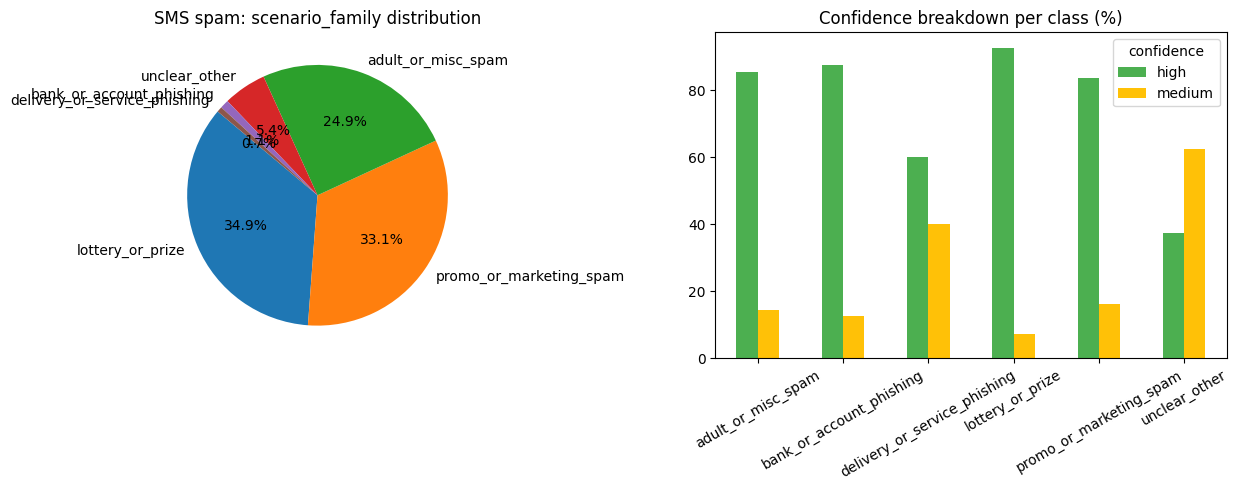

Saved: /Users/askar/projects/antifraud-deepfake-detection/v2/outputs/figures/annotation/sms_spam_annotation_distribution.png


In [7]:
from collections import Counter

df = pd.DataFrame(annotated)

cat_counts = df["scenario_family"].value_counts()
conf_by_cat = df.groupby(["scenario_family", "annotation_confidence"]).size().unstack(fill_value=0)

print("=" * 60)
print("Class distribution")
print("=" * 60)
for cls, n in cat_counts.items():
    pct = 100 * n / len(df)
    bar = "█" * int(pct / 2)
    print(f"  {cls:40s} {n:4d} ({pct:4.1f}%)  {bar}")

print()
print("Confidence breakdown per class:")
print(conf_by_cat.to_string())

# Pie chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct="%1.1f%%",
    startangle=140,
)
axes[0].set_title("SMS spam: scenario_family distribution")

conf_by_cat_pct = conf_by_cat.div(conf_by_cat.sum(axis=1), axis=0) * 100
conf_by_cat_pct.plot(kind="bar", ax=axes[1], color=["#4CAF50", "#FFC107", "#F44336"])
axes[1].set_title("Confidence breakdown per class (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="confidence")

plt.tight_layout()
fig_path = OUT_FIGS / "sms_spam_annotation_distribution.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

In [8]:
# ── 7. Audit section ───────────────────────────────────────────────────────
# For each class: print N_AUDIT random records so you can eyeball quality.
# Goal: check whether the category assignment makes sense.
# No code to edit here — just read the output.

N_AUDIT = 20
random.seed(42)

CORE_CLASSES = {"bank_or_account_phishing", "delivery_or_service_phishing"}

for cls in cat_counts.index:
    subset = df[df["scenario_family"] == cls]
    sample_size = min(N_AUDIT, len(subset))
    sample = subset.sample(sample_size, random_state=42)
    core_flag = "→ CORE CANDIDATE" if cls in CORE_CLASSES else "→ auxiliary / discard"

    print()
    print("▓" * 70)
    print(f"CLASS: {cls}  ({len(subset)} records)   {core_flag}")
    print("▓" * 70)
    print(f"Showing {sample_size} random samples — verify classification is correct:")
    print()
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        conf = row.get("annotation_confidence", "?")
        print(f"  [{i:02d}] [{conf}] {row['text']}")
    print()


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
CLASS: lottery_or_prize  (261 records)   → auxiliary / discard
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
Showing 20 random samples — verify classification is correct:

  [01] [high] GENT! We are trying to contact you. Last weekends draw shows that you won a £1000 prize GUARANTEED. Call 09064012160. Claim Code K52. Valid 12hrs only. 150ppm
  [02] [high] URGENT! Your Mobile number has been awarded with a £2000 prize GUARANTEED. Call 09058094454 from land line. Claim 3030. Valid 12hrs only
  [03] [high] Congratulations YOU'VE Won. You're a Winner in our August £1000 Prize Draw. Call 09066660100 NOW. Prize Code 2309.
  [04] [high] 09066362231 URGENT! Your mobile No 07xxxxxxxxx won a £2,000 bonus caller prize on 02/06/03! this is the 2nd attempt to reach YOU! call 09066362231 ASAP!
  [05] [high] Todays Voda numbers ending 5226 are selected to receive a ?350 award. If you hava a match please 

In [9]:
# ── 8. Quality checkpoint — low-confidence records ─────────────────────────
low_conf = df[df["annotation_confidence"] == "low"]
errors   = df[df.get("annotation_error", pd.Series(dtype=str)).notna()] if "annotation_error" in df.columns else pd.DataFrame()

print(f"Low-confidence records : {len(low_conf):,}  ({100*len(low_conf)/len(df):.1f}%)")
if "annotation_error" in df.columns:
    error_count = df["annotation_error"].notna().sum()
    print(f"API errors             : {error_count:,}")

if len(low_conf) > 0:
    print()
    print("All low-confidence records (review these carefully):")
    print()
    for _, row in low_conf.iterrows():
        print(f"  [{row['scenario_family']}]  {row['text']}")
else:
    print("\nNo low-confidence records — annotation quality looks good.")

Low-confidence records : 0  (0.0%)

No low-confidence records — annotation quality looks good.


In [10]:
# ── 9. Save summary ────────────────────────────────────────────────────────
summary_rows = []
for cls in sorted(VALID_CATEGORIES):
    subset = df[df["scenario_family"] == cls]
    n = len(subset)
    n_high   = (subset["annotation_confidence"] == "high").sum()
    n_medium = (subset["annotation_confidence"] == "medium").sum()
    n_low    = (subset["annotation_confidence"] == "low").sum()
    pct_high = round(100 * n_high / n, 1) if n else 0
    summary_rows.append({
        "scenario_family":   cls,
        "n":                 n,
        "pct_of_spam":       round(100 * n / len(df), 1) if len(df) else 0,
        "n_high_conf":       int(n_high),
        "n_medium_conf":     int(n_medium),
        "n_low_conf":        int(n_low),
        "pct_high_conf":     pct_high,
        "goes_to_core":      cls in CORE_CLASSES,
        "annotation_model":  ANNOTATION_MODEL,
    })

df_summary = pd.DataFrame(summary_rows).sort_values("n", ascending=False)

summary_path = INTERIM / "sms_spam_annotation_summary.csv"
df_summary.to_csv(summary_path, index=False)

print("Annotation summary:")
print(df_summary.to_string(index=False))
print(f"\nSaved: {summary_path}")

# Also save to outputs/tables for cross-notebook reference
df_summary.to_csv(OUT_TABLES / "sms_spam_annotation_summary.csv", index=False)

print()
core_total = df_summary[df_summary["goes_to_core"]]["n"].sum()
print(f"Core-candidate records (bank + delivery phishing): {core_total}")
print(f"Remaining (auxiliary / discard):                  {len(df) - core_total}")

Annotation summary:
             scenario_family   n  pct_of_spam  n_high_conf  n_medium_conf  n_low_conf  pct_high_conf  goes_to_core   annotation_model
            lottery_or_prize 261         34.9          242             19           0           92.7         False openai/gpt-4o-mini
     promo_or_marketing_spam 247         33.1          207             40           0           83.8         False openai/gpt-4o-mini
          adult_or_misc_spam 186         24.9          159             27           0           85.5         False openai/gpt-4o-mini
               unclear_other  40          5.4           15             25           0           37.5         False openai/gpt-4o-mini
    bank_or_account_phishing   8          1.1            7              1           0           87.5          True openai/gpt-4o-mini
delivery_or_service_phishing   5          0.7            3              2           0           60.0          True openai/gpt-4o-mini

Saved: /Users/askar/projects/antifraud-de

## 10 · Дозаполнение пропусков (тот же `sms_spam_annotated.jsonl`)

Если часть spam ещё без `scenario_family` (или вы расширили сырой `sms_spam.jsonl`), запустите **только** ячейки ниже — они дописывают строки **в конец того же файла**, не переразмечая уже готовые тексты (ключ `md5` от `text.strip()`, как в ячейке 5).

Настройте `MAX_NEW_GAP_THIS_RUN`, `BATCH_SIZE_GAP`, `SLEEP_SEC_GAP` и при необходимости выставьте `RUN_GAP_FILL = False`, чтобы пропустить этот блок.

In [ ]:
# ── 10a. Gap-fill config & run ────────────────────────────────────────────
RUN_GAP_FILL = True
MAX_NEW_GAP_THIS_RUN = 80
BATCH_SIZE_GAP = 12
SLEEP_SEC_GAP = 2.5

if not RUN_GAP_FILL:
    print("RUN_GAP_FILL is False — skip.")
else:
    import time
    from tqdm.auto import tqdm

    def _md5_key(t: str) -> str:
        return hashlib.md5(t.strip().encode("utf-8", errors="replace")).hexdigest()

    ann_path = INTERIM / "sms_spam_annotated.jsonl"
    if not ann_path.exists():
        raise FileNotFoundError(f"Run cells 5–6 first to create {ann_path}, or touch the file manually.")
    have: set[str] = set()
    for line in ann_path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        rec = json.loads(line)
        if rec.get("scenario_family"):
            have.add(_md5_key(rec.get("text", "")))

    sms_spam_rows = [r for r in spam_records]  # from cell 1
    missing = [r for r in sms_spam_rows if _md5_key(r.get("text", "")) not in have]
    print(f"Already annotated: {len(have):,} | Missing spam rows: {len(missing):,}")

    n_new = 0
    bi = 0
    for r in tqdm(missing[:MAX_NEW_GAP_THIS_RUN], desc="gap-fill SMS spam"):
        ann = annotate_one(r["text"])
        enriched = {
            **r,
            "scenario_family": ann["scenario_family"],
            "annotation_confidence": ann["annotation_confidence"],
            "annotation_model": ANNOTATION_MODEL,
        }
        if "annotation_error" in ann:
            enriched["annotation_error"] = ann["annotation_error"]
        with open(ann_path, "a", encoding="utf-8") as fout:
            fout.write(json.dumps(enriched, ensure_ascii=False) + "\n")
        have.add(_md5_key(r["text"]))
        n_new += 1
        bi += 1
        if bi >= BATCH_SIZE_GAP:
            bi = 0
            time.sleep(SLEEP_SEC_GAP)
    print(f"Appended {n_new} rows to {ann_path}")

In [ ]:
# ── 10b. Refresh dataframe after gap-fill (optional) ───────────────────────
_rgf = globals().get("RUN_GAP_FILL", False)
if _rgf:
    ann_path = INTERIM / "sms_spam_annotated.jsonl"
    annotated = [json.loads(l) for l in ann_path.read_text(encoding="utf-8").splitlines() if l.strip()]
    annotated = [r for r in annotated if r.get("label") == "spam" and r.get("scenario_family")]
    df = pd.DataFrame(annotated)
    print(f"Spam rows with scenario_family: {len(df):,}")
else:
    print("Run 10a first (sets RUN_GAP_FILL) or re-run cells 6–9 after gap-fill.")